In [185]:
%pip install fastapi uvicorn joblib pandas scikit-learn
%pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
    --------------------------------------- 0.3/10.5 MB ? eta -:--:--
   - -------------------------------------- 0.5/10.5 MB 922.1 kB/s eta 0:00:11
   -- ------------------------------------- 0.8/10.5 MB 978.6 kB/s eta 0:00:10
   --- ------------------------------------ 1.0/10.5 MB 1.0 MB/s eta 0:00:10
   ---- ----------------------------------- 1.3/10.5 MB 1.1 MB/s eta 0:00:09
   ----- ---------------------------------- 1.6/10.5 MB 1.1 MB/s eta 0:00:09
   ------ --------------------------------- 1.8/10.5 MB 1.1 MB/s eta 0:00:08
   ------- -------------------------------- 2.1/10.5 MB 1.1 MB/s eta 0:00:08
   --------- ------------------------------ 2.6/10.5 MB 1.2 MB/s eta 0:00:07
   ----------- ---------------------------- 3.1/10.5 MB 1.3 MB/s eta 0:00:06
   ------------


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [94]:
import fastapi
import uvicorn
import joblib
import pandas as pd
import sklearn

print("FastAPI:", fastapi.__version__)
print("Uvicorn: installed successfully")
print("Joblib: installed successfully")
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)

FastAPI: 0.141.1
Uvicorn: installed successfully
Joblib: installed successfully
Pandas: 3.0.2
Scikit-learn: 1.9.0


In [95]:
import pandas as pd
import numpy as np

In [96]:
df=pd.read_csv('data.csv')
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [97]:
df["date"].head()
df["city"].value_counts()
df["statezip"].value_counts()
df["country"].value_counts()

country
USA    4600
Name: count, dtype: int64

In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

In [99]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [100]:
df.describe(include='object')

C:\Users\DELL\AppData\Local\Temp\ipykernel_27152\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,date,street,city,statezip,country
count,4600,4600,4600,4600,4600
unique,70,4525,44,77,1
top,2014-06-23 00:00:00,2520 Mulberry Walk NE,Seattle,WA 98103,USA
freq,142,4,1573,148,4600


In [101]:
df.shape

(4600, 18)

# IDENTIFYING MISSING VALUES

In [102]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": df.isnull().mean() * 100
})

missing.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
date,0,0.0
price,0,0.0
bedrooms,0,0.0
bathrooms,0,0.0
sqft_living,0,0.0
sqft_lot,0,0.0
floors,0,0.0
waterfront,0,0.0
view,0,0.0
condition,0,0.0


# CHECKING FOR DUPLICATES

In [103]:
df.duplicated().sum()

np.int64(0)

In [104]:
df[df.duplicated()]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country


# CHECKING FOR INCONSISTENT FORMATS

In [105]:
categorical_columns = [
    "waterfront",
    "view",
    "condition",
    "street",
    "city",
    "statezip",
    "country"
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- waterfront ---
waterfront
0    4567
1      33
Name: count, dtype: int64

--- view ---
view
0    4140
2     205
3     116
4      70
1      69
Name: count, dtype: int64

--- condition ---
condition
3    2875
4    1252
5     435
2      32
1       6
Name: count, dtype: int64

--- street ---
street
2520 Mulberry Walk NE    4
2500 Mulberry Walk NE    3
Burke-Gilman Trail       2
23017 SE 281st Ct        2
35229 SE Terrace St      2
                        ..
501 N 143rd St           1
14855 SE 10th Pl         1
759 Ilwaco Pl NE         1
5148 S Creston St        1
18717 SE 258th St        1
Name: count, Length: 4525, dtype: int64

--- city ---
city
Seattle                1573
Renton                  293
Bellevue                286
Redmond                 235
Kirkland                187
Issaquah                187
Kent                    185
Auburn                  176
Sammamish               175
Federal Way             148
Shoreline               123
Woodinville             115
Maple Va

In [106]:
numerical_columns = df.select_dtypes(include=np.number).columns

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
price,4600.0,551962.988473,563834.702547,0.0,322875.00,460943.461539,654962.50,26590000.0
bedrooms,4600.0,3.400870,0.908848,0.0,3.00,3.000000,4.00,9.0
bathrooms,4600.0,2.160815,0.783781,0.0,1.75,2.250000,2.50,8.0
sqft_living,4600.0,2139.346957,963.206916,370.0,1460.00,1980.000000,2620.00,13540.0
sqft_lot,4600.0,14852.516087,35884.436145,638.0,5000.75,7683.000000,11001.25,1074218.0
floors,4600.0,1.512065,0.538288,1.0,1.00,1.500000,2.00,3.5
waterfront,4600.0,0.007174,0.084404,0.0,0.00,0.000000,0.00,1.0
view,4600.0,0.240652,0.778405,0.0,0.00,0.000000,0.00,4.0
condition,4600.0,3.451739,0.677230,1.0,3.00,3.000000,4.00,5.0
sqft_above,4600.0,1827.265435,862.168977,370.0,1190.00,1590.000000,2300.00,9410.0


# OUTLIER ANALYSIS

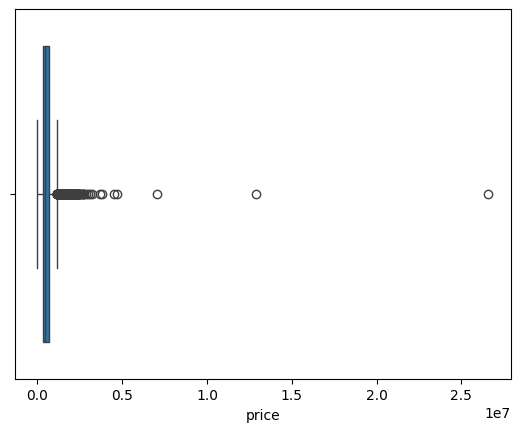

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["price"])
plt.show()

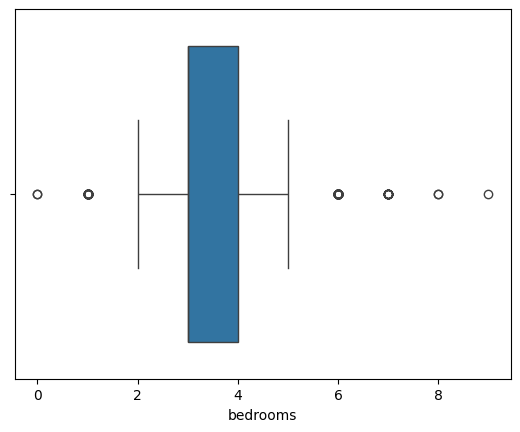

In [108]:
sns.boxplot(x=df["bedrooms"])
plt.show()

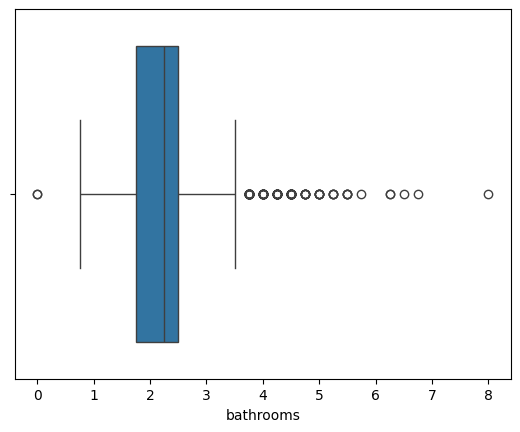

In [109]:
sns.boxplot(x=df["bathrooms"])
plt.show()

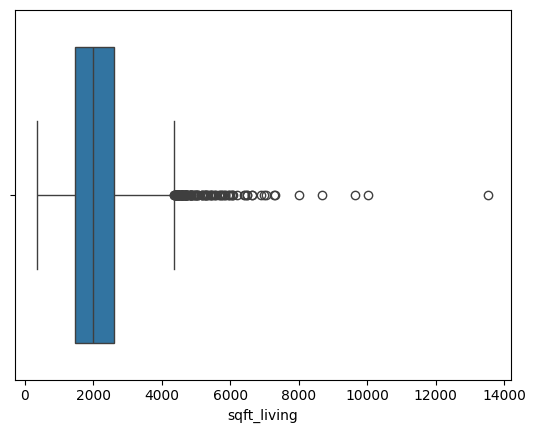

In [110]:
sns.boxplot(x=df["sqft_living"])
plt.show()

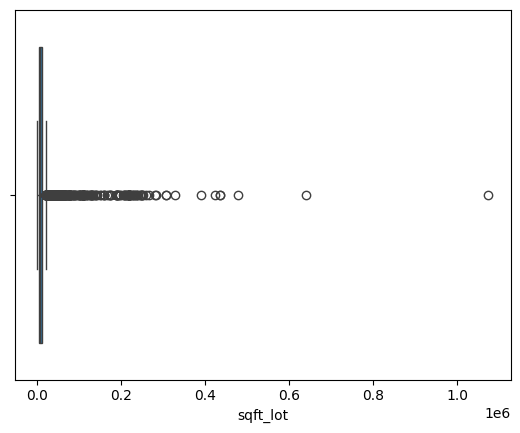

In [111]:
sns.boxplot(x=df["sqft_lot"])
plt.show()

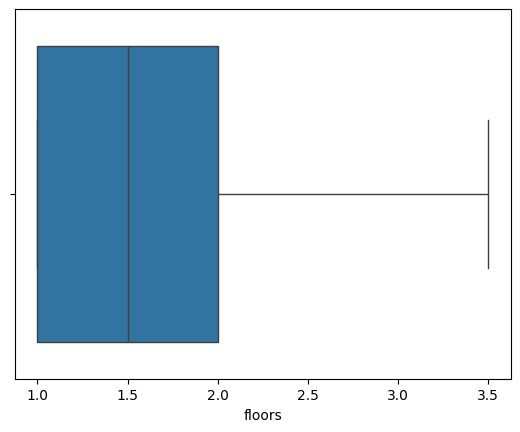

In [112]:
sns.boxplot(x=df["floors"])
plt.show()

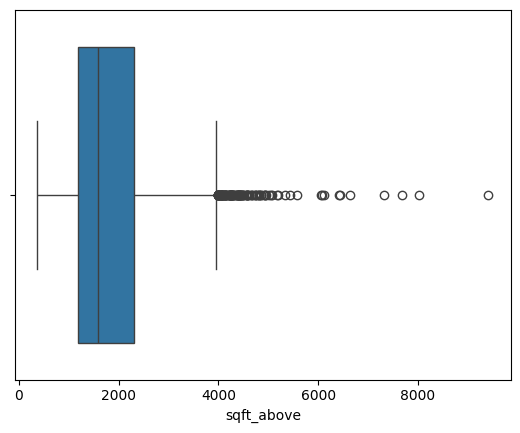

In [113]:
sns.boxplot(x=df["sqft_above"])
plt.show()

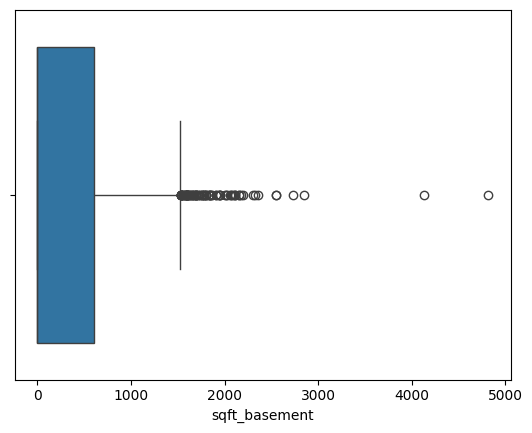

In [114]:
sns.boxplot(x=df["sqft_basement"])
plt.show()

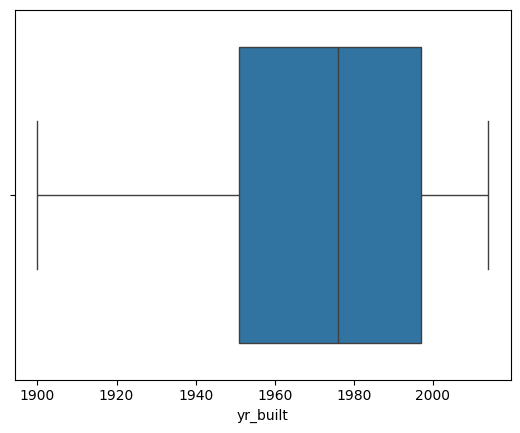

In [115]:
sns.boxplot(x=df["yr_built"])
plt.show()

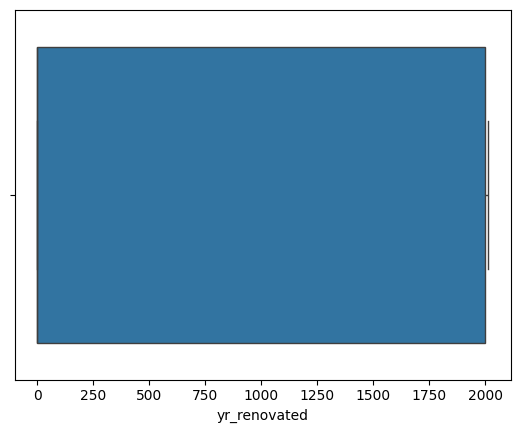

In [116]:
sns.boxplot(x=df["yr_renovated"])
plt.show()

# EDA PLAN

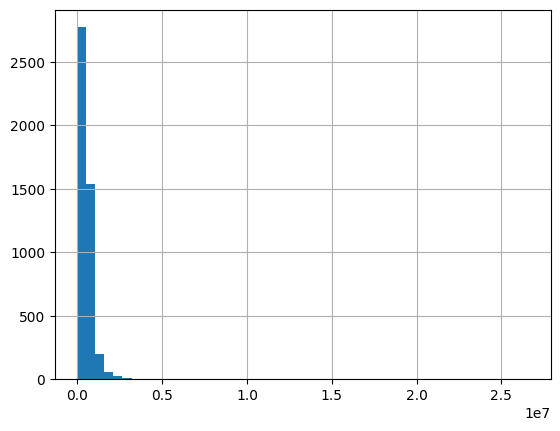

In [117]:
df["price"].hist(bins=50)
plt.show()

In [118]:
df["bedrooms"].value_counts().sort_index()

bedrooms
0.0       2
1.0      38
2.0     566
3.0    2032
4.0    1531
5.0     353
6.0      61
7.0      14
8.0       2
9.0       1
Name: count, dtype: int64

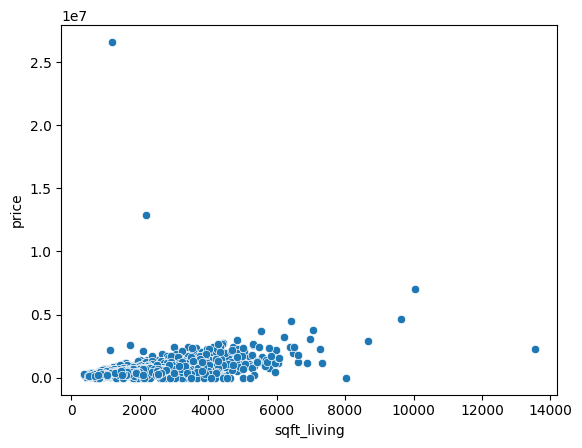

In [119]:
# Which Variable Appears to Influence House Price the Most? (Correlation Analysis)
sns.scatterplot(data=df, x="sqft_living", y="price")
plt.show()

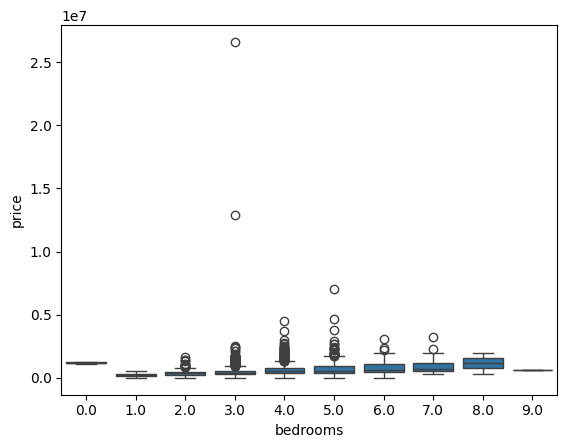

In [120]:
sns.boxplot(data=df, x="bedrooms", y="price")
plt.show()

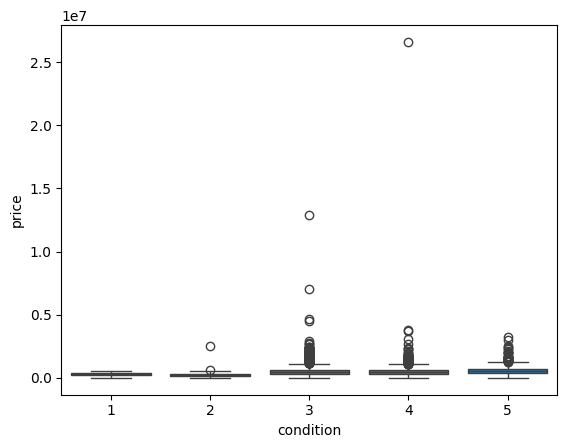

In [121]:
sns.boxplot(data=df, x="condition", y="price")
plt.show()

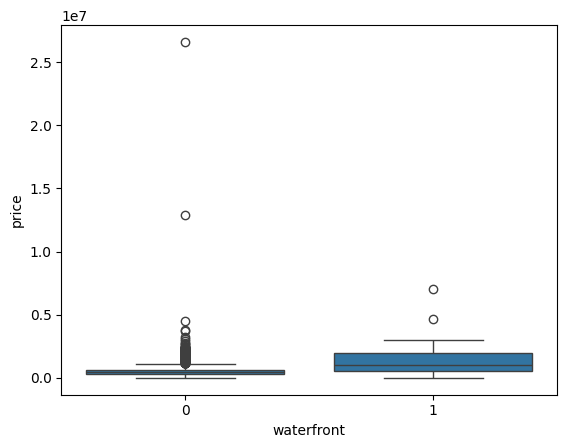

In [122]:
sns.boxplot(data=df, x="waterfront", y="price")
plt.show()

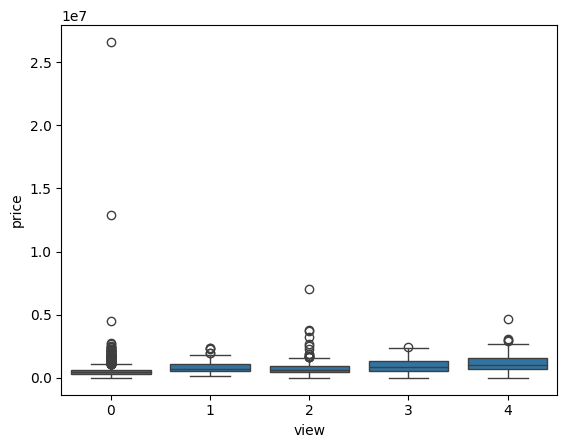

In [123]:
sns.boxplot(data=df, x="view", y="price")
plt.show()

In [124]:
df.groupby("city")["price"].agg(["count", "mean", "median"]).sort_values(
    "median", ascending=False
)

,count,mean,median
city,,,
Medina,11,2.046559e+06,2100000.0
Yarrow Point,4,1.194838e+06,1397000.0
Clyde Hill,11,1.321945e+06,1300000.0
Mercer Island,86,1.123818e+06,948750.0
Beaux Arts Village,1,7.450000e+05,745000.0
Bellevue,286,8.471807e+05,721500.0
Sammamish,175,6.869176e+05,665000.0
Redmond,235,6.676495e+05,638000.0
Newcastle,33,6.660467e+05,602500.0


# FEATURE ENGINEERING

In [125]:
# HOUSE AGE
df["house_age"] = df["yr_built"].max() - df["yr_built"]

In [126]:
# RENOVATION INDICATORS
df["was_renovated"] = (df["yr_renovated"] > 0).astype(int)

In [127]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [128]:
categorical_features = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['date', 'street', 'city', 'statezip', 'country']

Numerical features:
['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'house_age', 'was_renovated']


C:\Users\DELL\AppData\Local\Temp\ipykernel_27152\3941328504.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(


In [129]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

In [130]:
print(df["date"].head())
print("\nData type:")
print(df["date"].dtype)

0    2014-05-02 00:00:00
1    2014-05-02 00:00:00
2    2014-05-02 00:00:00
3    2014-05-02 00:00:00
4    2014-05-02 00:00:00
Name: date, dtype: str

Data type:
str


# DATE ENGINEERING

In [131]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(df["date"].head())
print("\nData type after conversion:")
print(df["date"].dtype)

0   2014-05-02
1   2014-05-02
2   2014-05-02
3   2014-05-02
4   2014-05-02
Name: date, dtype: datetime64[us]

Data type after conversion:
datetime64[us]


In [132]:
df["sale_year"] = df["date"].dt.year
df["sale_month"] = df["date"].dt.month

print(df[["date", "sale_year", "sale_month"]].head(10))

        date  sale_year  sale_month
0 2014-05-02       2014           5
1 2014-05-02       2014           5
2 2014-05-02       2014           5
3 2014-05-02       2014           5
4 2014-05-02       2014           5
5 2014-05-02       2014           5
6 2014-05-02       2014           5
7 2014-05-02       2014           5
8 2014-05-02       2014           5
9 2014-05-02       2014           5


In [133]:
print("Missing dates:", df["date"].isna().sum())
print("Missing sale years:", df["sale_year"].isna().sum())
print("Missing sale months:", df["sale_month"].isna().sum())

Missing dates: 0
Missing sale years: 0
Missing sale months: 0


In [134]:
df = df.drop(columns=["date"])

print(df.head())

       price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  \
0   313000.0       3.0       1.50         1340      7912     1.5           0   
1  2384000.0       5.0       2.50         3650      9050     2.0           0   
2   342000.0       3.0       2.00         1930     11947     1.0           0   
3   420000.0       3.0       2.25         2000      8030     1.0           0   
4   550000.0       4.0       2.50         1940     10500     1.0           0   

   view  condition  sqft_above  ...  yr_built  yr_renovated  \
0     0          3        1340  ...      1955          2005   
1     4          5        3370  ...      1921             0   
2     0          4        1930  ...      1966             0   
3     0          4        1000  ...      1963             0   
4     0          4        1140  ...      1976          1992   

                     street       city  statezip country house_age  \
0      18810 Densmore Ave N  Shoreline  WA 98133     USA        59   


# MACHINE LEARNING PIPELINE

In [135]:
y = df["price"]

In [136]:
X = df.drop(columns=["price"])

In [137]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [138]:
# Separate features and target

X = df.drop(columns=["price"])
y = df["price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4600, 20)
y shape: (4600,)


In [139]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (3680, 20)
Testing features: (920, 20)
Training target: (3680,)
Testing target: (920,)


In [140]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np

In [141]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

print("Linear Regression pipeline created successfully.")
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

print("Linear Regression pipeline created successfully.")

Linear Regression pipeline created successfully.
Linear Regression pipeline created successfully.


In [142]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# 1. Grab feature names directly from X_train to avoid any column mismatch
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

# 2. Build a fresh preprocessor matched to X_train
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# 3. Define and fit the Linear Regression pipeline
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
print("Linear Regression model trained successfully.")

C:\Users\DELL\AppData\Local\Temp\ipykernel_27152\641486473.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


Linear Regression model trained successfully.


In [143]:
# GENERATE PREDICTIONS
y_pred_linear = linear_model.predict(X_test)

print("Predictions generated successfully.")
print("First 10 predictions:")
print(y_pred_linear[:10])

Predictions generated successfully.
First 10 predictions:
[ 123513.80744202 -262884.61762458 3333021.91854749   15342.64559536
 -558202.17935516 1324499.36790814 -205707.75070846  226648.18748599
  743591.91547328  875089.06750513]


In [144]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("--------------------------------")
print(f"MAE:  ${mae_linear:,.2f}")
print(f"RMSE: ${rmse_linear:,.2f}")
print(f"R²:   {r2_linear:.4f}")

Linear Regression Performance
--------------------------------
MAE:  $926,860.49
RMSE: $2,158,021.31
R²:   -3.5664


In [145]:
target = "price"

categorical_features = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

if target in numerical_features:
    numerical_features.remove(target)

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['street', 'city', 'statezip', 'country']

Numerical features:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'house_age', 'was_renovated']


C:\Users\DELL\AppData\Local\Temp\ipykernel_27152\1758039155.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(


In [146]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Numerical preprocessing
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine both preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [147]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# MODEL DEVELOPMENT

In [148]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Dynamically get current categorical and numerical features from X_train
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Re-create preprocessor using active columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Fit and transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data shape:", X_train_processed.shape)
print("Testing data shape:", X_test_processed.shape)

C:\Users\DELL\AppData\Local\Temp\ipykernel_27152\1851239345.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()


Training data shape: (3680, 3771)
Testing data shape: (920, 3771)


In [149]:
# RECREATING THE PREPROCESSOR
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessor recreated successfully.")

Preprocessor recreated successfully.


In [150]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (3680, 20)
Testing set: (920, 20)


In [151]:
# PROCESS THE DATA
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training data:", X_train_processed.shape)
print("Processed testing data:", X_test_processed.shape)

Processed training data: (3680, 3771)
Processed testing data: (920, 3771)


# TRAINING MY FIRST MODEL

In [152]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [153]:
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [154]:
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest predictions generated successfully.")

Random Forest predictions generated successfully.


In [155]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("--------------------------------")
print(f"MAE:  ${mae_rf:,.2f}")
print(f"RMSE: ${rmse_rf:,.2f}")
print(f"R²:   {r2_rf:.4f}")

Random Forest Performance
--------------------------------
MAE:  $155,371.77
RMSE: $984,576.08
R²:   0.0495


In [156]:
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

print("Gradient Boosting pipeline created successfully.")

Gradient Boosting pipeline created successfully.


In [157]:
gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [158]:
y_pred_gb = gradient_boosting_model.predict(X_test)

print("Gradient Boosting predictions generated successfully.")

Gradient Boosting predictions generated successfully.


In [159]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)

rmse_gb = np.sqrt(
    mean_squared_error(y_test, y_pred_gb)
)

r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Performance")
print("--------------------------------")
print(f"MAE:  ${mae_gb:,.2f}")
print(f"RMSE: ${rmse_gb:,.2f}")
print(f"R²:   {r2_gb:.4f}")

Gradient Boosting Performance
--------------------------------
MAE:  $158,090.61
RMSE: $981,957.36
R²:   0.0545


# MODEL COMPARISON AND SELECTION

In [160]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae_linear,
        mae_rf,
        mae_gb
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf,
        rmse_gb
    ],
    "R²": [
        r2_linear,
        r2_rf,
        r2_gb
    ]
})

model_comparison = model_comparison.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

model_comparison

,Model,MAE,RMSE,R²
0,Gradient Boosting,158090.614433,9.819574e+05,0.054524
1,Random Forest,155371.772830,9.845761e+05,0.049474
2,Linear Regression,926860.490145,2.158021e+06,-3.566429


# AUTOMATICALLY IDENTIFYING THE BEST MODEL

In [161]:
best_model_name = model_comparison.loc[0, "Model"]

print("Best model based on R²:", best_model_name)
print(f"MAE:  ${model_comparison.loc[0, 'MAE']:,.2f}")
print(f"RMSE: ${model_comparison.loc[0, 'RMSE']:,.2f}")
print(f"R²:   {model_comparison.loc[0, 'R²']:.4f}")

Best model based on R²: Gradient Boosting
MAE:  $158,090.61
RMSE: $981,957.36
R²:   0.0545


# VISUALIZING PREDICTIONS

In [162]:
if best_model_name == "Linear Regression":
    best_model = linear_model
    y_pred_best = y_pred_linear

elif best_model_name == "Random Forest":
    best_model = random_forest_model
    y_pred_best = y_pred_rf

else:
    best_model = gradient_boosting_model
    y_pred_best = y_pred_gb

print("Selected model:", best_model_name)

Selected model: Gradient Boosting


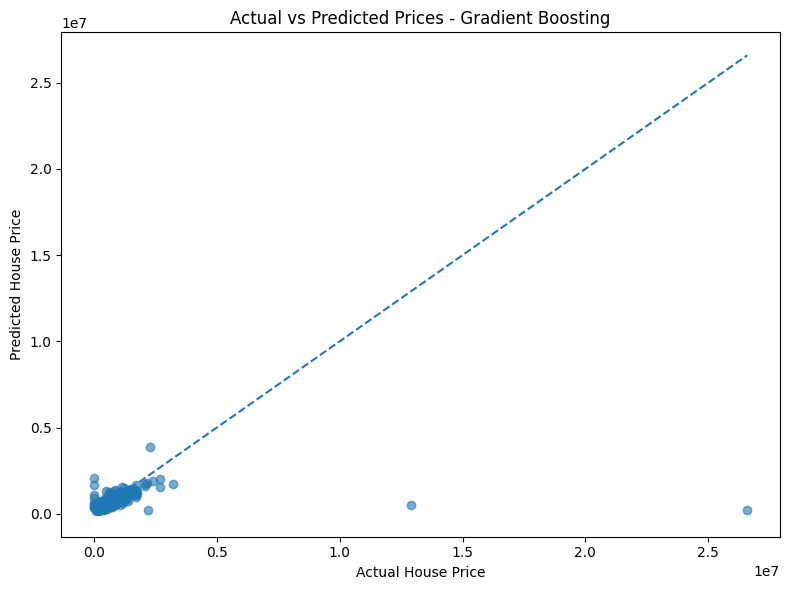

In [163]:
# ACTUAL VS PREDICTED SCATTER PLOT
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_best,
    alpha=0.6
)

# Perfect prediction reference line
min_price = min(y_test.min(), y_pred_best.min())
max_price = max(y_test.max(), y_pred_best.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title(f"Actual vs Predicted Prices - {best_model_name}")

plt.tight_layout()
plt.show()

# RESIDUAL ANALYSIS

In [164]:
# INVESTIGATING WHERE THE MODEL IS MAKING MISTAKES
residuals = y_test - y_pred_best

print("Residual summary:")
print(residuals.describe())

Residual summary:
count    9.200000e+02
mean     3.250695e+04
std      9.819530e+05
min     -2.086753e+06
25%     -7.852749e+04
50%     -1.699786e+04
75%      6.512721e+04
max      2.634227e+07
Name: price, dtype: float64


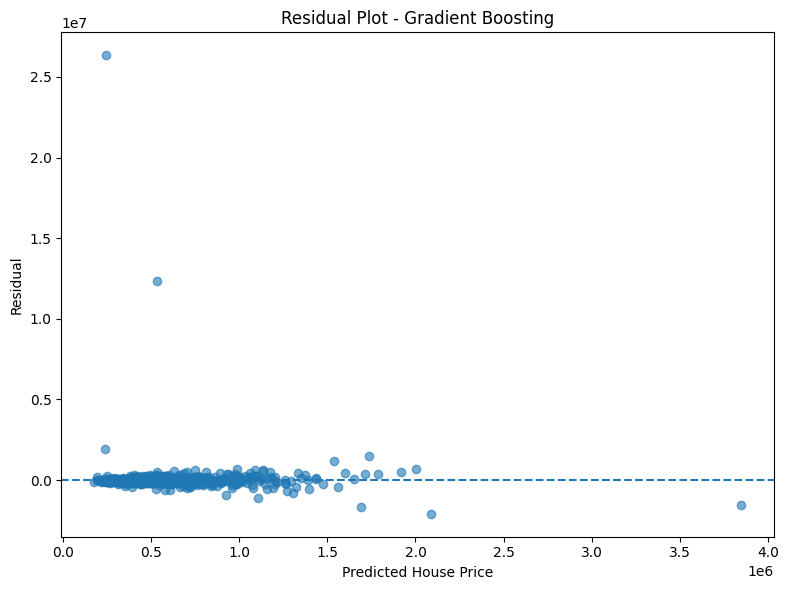

In [165]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_best,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted House Price")
plt.ylabel("Residual")
plt.title(f"Residual Plot - {best_model_name}")

plt.tight_layout()
plt.show()

In [166]:
if best_model_name in ["Random Forest", "Gradient Boosting"]:

    model = best_model.named_steps["model"]
    preprocessor_fitted = best_model.named_steps["preprocessor"]

    feature_names = preprocessor_fitted.get_feature_names_out()

    importances = model.feature_importances_

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    print(feature_importance.head(15))

else:
    print(
        "The selected model is Linear Regression. "
        "We will use permutation importance for this model."
    )

                          Feature  Importance
3759             num__sqft_living    0.569643
3682       cat__statezip_WA 98004    0.054981
3763                    num__view    0.040223
3765              num__sqft_above    0.030068
3670            cat__city_Seattle    0.026567
3732       cat__statezip_WA 98112    0.015826
3703       cat__statezip_WA 98039    0.015307
3767                num__yr_built    0.012827
3758               num__bathrooms    0.012498
3760                num__sqft_lot    0.011122
3657             cat__city_Medina    0.011008
3639           cat__city_Bellevue    0.010996
3658      cat__city_Mercer Island    0.010037
3769               num__house_age    0.009748
1988  cat__street_2826 21st Ave W    0.009059


# PLOTTING THE TOP FEATURES 

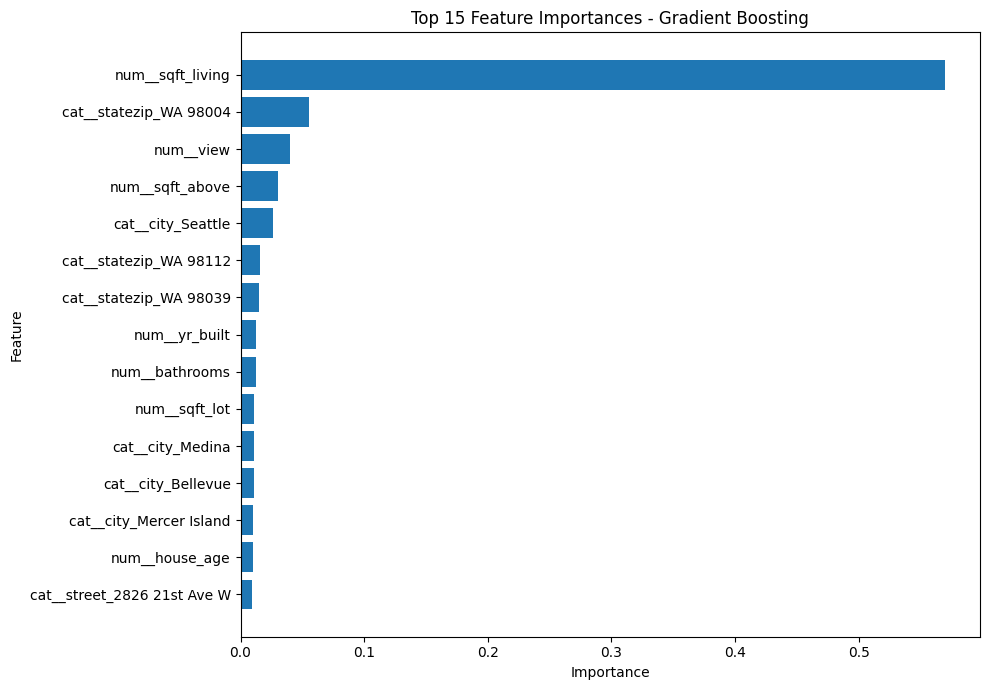

In [167]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Top 15 Feature Importances - {best_model_name}")

plt.tight_layout()
plt.show()

In [168]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold cross-validation setup complete.")

5-fold cross-validation setup complete.


In [169]:
linear_cv_scores = cross_val_score(
    linear_model,
    X,
    y,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

print("Linear Regression Cross-Validation R² Scores:")
print(linear_cv_scores)

print(f"\nMean R²: {linear_cv_scores.mean():.4f}")
print(f"Standard Deviation: {linear_cv_scores.std():.4f}")

Linear Regression Cross-Validation R² Scores:
[ -3.56642821 -26.02396491 -63.73375609   0.58564553 -15.75452508]

Mean R²: -21.6986
Standard Deviation: 23.0059


In [170]:
rf_cv_scores = cross_val_score(
    random_forest_model,
    X,
    y,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

print("Random Forest Cross-Validation R² Scores:")
print(rf_cv_scores)

print(f"\nMean R²: {rf_cv_scores.mean():.4f}")
print(f"Standard Deviation: {rf_cv_scores.std():.4f}")

Random Forest Cross-Validation R² Scores:
[0.04869523 0.64680276 0.58958561 0.66204167 0.66840096]

Mean R²: 0.5231
Standard Deviation: 0.2388


In [171]:
gb_cv_scores = cross_val_score(
    gradient_boosting_model,
    X,
    y,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

print("Gradient Boosting Cross-Validation R² Scores:")
print(gb_cv_scores)

print(f"\nMean R²: {gb_cv_scores.mean():.4f}")
print(f"Standard Deviation: {gb_cv_scores.std():.4f}")

Gradient Boosting Cross-Validation R² Scores:
[0.0547351  0.67737855 0.60771135 0.69789787 0.70896845]

Mean R²: 0.5493
Standard Deviation: 0.2498


In [172]:
# Creating the final validation comparison
cv_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Mean CV R²": [
        linear_cv_scores.mean(),
        rf_cv_scores.mean(),
        gb_cv_scores.mean()
    ],
    "CV R² Std": [
        linear_cv_scores.std(),
        rf_cv_scores.std(),
        gb_cv_scores.std()
    ]
})

cv_comparison = cv_comparison.sort_values(
    by="Mean CV R²",
    ascending=False
).reset_index(drop=True)

cv_comparison

,Model,Mean CV R²,CV R² Std
0,Gradient Boosting,0.549338,0.249794
1,Random Forest,0.523105,0.238830
2,Linear Regression,-21.698606,23.005905


In [173]:
# SELECTING THE FINAL MODEL BASED ON CROSS-VALIDATION RESULTS
best_cv_model_name = cv_comparison.loc[0, "Model"]

if best_cv_model_name == "Linear Regression":
    final_model = linear_model

elif best_cv_model_name == "Random Forest":
    final_model = random_forest_model

else:
    final_model = gradient_boosting_model

print("Final model selected:", best_cv_model_name)

Final model selected: Gradient Boosting


In [174]:
# RETRAINING THE FINAL MODEL ON THE TRAINING DATA
final_model.fit(X_train, y_train)

print("Final model trained successfully.")

Final model trained successfully.


In [175]:
final_predictions = final_model.predict(X_test)

final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(y_test, final_predictions)
)

final_r2 = r2_score(
    y_test,
    final_predictions
)

print("FINAL MODEL PERFORMANCE")
print("=" * 35)
print(f"Model: {best_cv_model_name}")
print(f"MAE:   ${final_mae:,.2f}")
print(f"RMSE:  ${final_rmse:,.2f}")
print(f"R²:    {final_r2:.4f}")

FINAL MODEL PERFORMANCE
Model: Gradient Boosting
MAE:   $158,090.61
RMSE:  $981,957.36
R²:    0.0545


# SAVING THE COMPLETE PIPELINE

In [176]:
import joblib

joblib.dump(
    final_model,
    "house_price_prediction_pipeline.pkl"
)

print("Complete prediction pipeline saved successfully.")

Complete prediction pipeline saved successfully.


# TESTING THE MODEL WITH ONE REAL PROPERTY

In [177]:
sample_property = X_test.iloc[[0]]

predicted_price = final_model.predict(sample_property)[0]

actual_price = y_test.iloc[0]

print(f"Actual Price:    ${actual_price:,.2f}")
print(f"Predicted Price: ${predicted_price:,.2f}")

Actual Price:    $544,000.00
Predicted Price: $429,137.27


In [178]:
import joblib

joblib.dump(final_model, "house_price_model.pkl")
joblib.dump(preprocessor, "house_price_preprocessor.pkl")

print("Model and preprocessor saved successfully.")

Model and preprocessor saved successfully.


In [179]:
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI(
    title="House Price Prediction API",
    description="API for predicting house sale prices",
    version="1.0"
)

print("FastAPI application created successfully.")

FastAPI application created successfully.


In [180]:
class HouseFeatures(BaseModel):
    bedrooms: float
    bathrooms: float
    sqft_living: float
    sqft_lot: float
    floors: float
    waterfront: int
    view: int
    condition: int
    sqft_above: float
    sqft_basement: float
    yr_built: int
    yr_renovated: int
    was_renovated: int
    sale_year: int
    sale_month: int
    street: str
    city: str
    statezip: str
    country: str

In [181]:
@app.post("/predict")
def predict_price(house: HouseFeatures):

    # Convert incoming JSON data into a DataFrame
    input_data = pd.DataFrame([house.model_dump()])

    # Apply the same preprocessing used during model training
    processed_data = preprocessor.transform(input_data)

    # Make prediction
    prediction = final_model.predict(processed_data)[0]

    return {
        "predicted_price": round(float(prediction), 2)
    }

In [182]:
# Test that the preprocessor and final model work together

sample_house = X_test.iloc[[0]].copy()

processed_sample = preprocessor.transform(sample_house)

prediction = final_model.predict(sample_house)[0]

print("Preprocessed shape:", processed_sample.shape)
print("Sample prediction:", round(float(prediction), 2))
print("Model and preprocessor are compatible.")

Preprocessed shape: (1, 3771)
Sample prediction: 429137.27
Model and preprocessor are compatible.


In [183]:
@app.get("/")
def home():
    return {
        "message": "House Price Prediction API is running successfully."
    }

In [184]:
%%writefile app.py

from fastapi import FastAPI
from pydantic import BaseModel
import pandas as pd
import joblib

# Load model and preprocessor
model = joblib.load("house_price_model.pkl")
preprocessor = joblib.load("house_price_preprocessor.pkl")

app = FastAPI(
    title="House Price Prediction API",
    description="API for predicting house sale prices",
    version="1.0"
)


class HouseFeatures(BaseModel):
    bedrooms: float
    bathrooms: float
    sqft_living: float
    sqft_lot: float
    floors: float
    waterfront: int
    view: int
    condition: int
    sqft_above: float
    sqft_basement: float
    yr_built: int
    yr_renovated: int
    was_renovated: int
    sale_year: int
    sale_month: int
    street: str
    city: str
    statezip: str
    country: str


@app.get("/")
def home():
    return {
        "message": "House Price Prediction API is running successfully."
    }


@app.post("/predict")
def predict_price(house: HouseFeatures):

    input_data = pd.DataFrame([house.model_dump()])

    processed_data = preprocessor.transform(input_data)

    prediction = model.predict(processed_data)[0]

    return {
        "predicted_price": round(float(prediction), 2)
    }

Overwriting app.py
